In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, kendalltau
from sklearn.preprocessing import StandardScaler

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv("marketing_advanced.csv", encoding="euc-kr")

In [4]:
df.drop

<bound method DataFrame.drop of                                 order_id                       customer_id  \
0       e22acc9c116caa3f2b7121bbb380d08e  0000366f3b9a7992bf8c76cfdf3221e2   
1       3594e05a005ac4d06a72673270ef9ec9  0000b849f77a49e4a4ce2b2a4ca5be3f   
2       b33ec3b699337181488304f362a6b734  0000f46a3911fa3c0805444483337064   
3       41272756ecddd9a9ed0180413cc22fb6  0000f6ccb0745a6a4b88665a16c9f078   
4       d957021f1127559cd947b62533f484f7  0004aac84e0df4da2b147fca70cf8255   
...                                  ...                               ...   
104894  725cf8e9c24e679a8a5a32cb92c9ce1e  fffcf5a5ff07b0908bd4e2dbc735a684   
104895  c71b9252fd7b3b263aaa4cb09319a323  fffea47cd6d3cc0a88bd621562a9d061   
104896  fdc45e6c7555e6cb3cc0daca2557dbe1  ffff371b4d645b6ecea244b27531430a   
104897  94d3ee0bc2a0af9d4fa47a4d63616e8d  ffff5962728ec6157033ef9805bacc48   
104898  f79a35da168301ae56922475da21117b  ffffd2657e2aad2907e67c3e9daecbeb   

       order_status order_purch

### RFM
Recency (최근성):\
    - 최근에 구매한 고객기준 == 2025-02-03 11:34:00\
Frequency (빈도):\
    - 특정 기간동안 구매빈도 == 대부분 1회 구매, 재구매 매우 낮음(재구매 고객 비율 약 8%)\
Monetary (금액):\
    - 특정기간동안 구매금액

In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors = 'coerce')

df_sorted = df.sort_values(by=['customer_id', 'order_purchase_timestamp'], ascending=[True, False])
df_sorted['prev_purchase'] = df_sorted.groupby('customer_id')['order_purchase_timestamp'].shift(-1)
df_sorted['days_diff'] = (df_sorted['order_purchase_timestamp'] - df_sorted['prev_purchase']).dt.days

latest_gap = df_sorted.groupby('customer_id').head(1).reset_index(drop=True)
latest_gap = latest_gap[['customer_id', 'order_purchase_timestamp', 'prev_purchase', 'days_diff']]
latest_gap.columns = ['고객ID', '최근구매일', '이전구매일', '날짜차이(일)']
latest_gap

,고객ID,최근구매일,이전구매일,날짜차이(일)
0,0000366f3b9a7992bf8c76cfdf3221e2,2024-10-10 16:29:00,NaT,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2024-10-07 17:47:00,NaT,NaN
2,0000f46a3911fa3c0805444483337064,2023-08-10 16:35:00,NaT,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,2024-03-12 15:03:00,NaT,NaN
4,0004aac84e0df4da2b147fca70cf8255,2024-04-14 13:49:00,NaT,NaN
...,...,...,...,...
95414,fffcf5a5ff07b0908bd4e2dbc735a684,2023-11-08 15:00:00,2023-11-08 13:35:00,0.0
95415,fffea47cd6d3cc0a88bd621562a9d061,2024-05-10 12:45:00,NaT,NaN
95416,ffff371b4d645b6ecea244b27531430a,2023-07-07 04:15:00,NaT,NaN
95417,ffff5962728ec6157033ef9805bacc48,2024-10-02 20:34:00,NaT,NaN


In [6]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

latest_customer = df.loc[df['order_purchase_timestamp'].idxmax(), ['customer_id', 'order_purchase_timestamp']]
latest_customer

customer_id                 ff22e30958c13ffe219db7d711e8f564
order_purchase_timestamp                 2025-02-03 11:34:00
Name: 104536, dtype: object

In [7]:
category2_avg_price = (
    df.groupby('category2')['price']
    .mean()
    .reset_index()
    .rename(columns={'category2': '카테고리2', 'price': '평균가격'})
    .sort_values(by='평균가격', ascending=False)
)
category2_avg_price.round(2)

,카테고리2,평균가격
29,책상/책장,138.80
36,화장대,134.10
31,침대,129.29
27,음향가전,127.25
2,거실장/테이블,124.71
3,건강가전,121.47
0,1인가구,120.04
9,냉장고,115.71
23,야외가구,114.94
28,주방가전,110.00


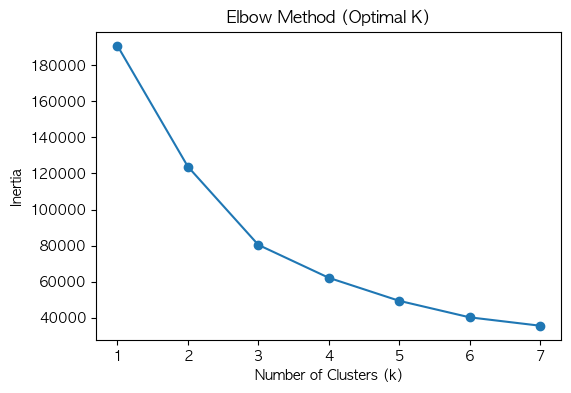

In [8]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['total_payment'] = df['price'] + df['shipping_charges']

rfm_rm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (df['order_purchase_timestamp'].max() - x.max()).days,
    'total_payment': 'sum'
}).reset_index()

rfm_rm.columns = ['customer_id', 'Recency', 'Monetary']

scaler = StandardScaler()
rm_scaled = scaler.fit_transform(rfm_rm[['Recency', 'Monetary']])

inertia = []
K = range(1, 8)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'o-')
plt.title('Elbow Method (Optimal K)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_rm['Cluster'] = kmeans.fit_predict(rm_scaled)

rfm_rm.groupby('Cluster')[['Recency', 'Monetary']].mean()
df0 = rfm_rm[rfm_rm['Cluster'] == 0]
df1 = rfm_rm[rfm_rm['Cluster'] == 1]
df2 = rfm_rm[rfm_rm['Cluster'] == 2]

| Cluster | Recency (일) | Monetary (지출 금액) | 해석                                        |
| ------- | ----------- | ---------------- | ----------------------------------------- |
| **0**   | 198.5       | 167.08           | 중간 정도의 최근성, **가장 높은 금액 소비 그룹 (VIP 후보)**   |
| **1**   | 143.1       | 76.39            | **가장 최근에 구매한 그룹**, 그러나 금액은 적음 (신규/활성 고객)  |
| **2**   | 417.2       | 86.97            | **가장 오래 전에 구매**, 금액도 낮음 (이탈 고객 또는 비활성 고객) |

In [9]:
df0

,customer_id,Recency,Monetary,Cluster
3,0000f6ccb0745a6a4b88665a16c9f078,327,145.17,0
4,0004aac84e0df4da2b147fca70cf8255,294,126.15,0
7,00053a61a98854899e70ed204dd4bafe,189,166.63,0
11,00082cbe03e478190aadbea78542e933,289,187.09,0
12,00090324bbad0e9342388303bb71ba0a,163,143.17,0
...,...,...,...,...
95405,fff3e1d7bc75f11dc7670619b2e61840,44,163.58,0
95406,fff5eb4918b2bf4b2da476788d42051c,62,404.54,0
95408,fff7219c86179ca6441b8f37823ba3d3,251,126.17,0
95414,fffcf5a5ff07b0908bd4e2dbc735a684,452,679.34,0


### VIP후보의 기본구조

In [10]:
df0.info()
df0.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
Index: 17241 entries, 3 to 95417
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  17241 non-null  object 
 1   Recency      17241 non-null  int64  
 2   Monetary     17241 non-null  float64
 3   Cluster      17241 non-null  int32  
dtypes: float64(1), int32(1), int64(1), object(1)
memory usage: 606.1+ KB


,Recency,Monetary,Cluster
count,17241.00,17241.00,17241.0
mean,198.50,167.08,0.0
std,116.25,56.96,0.0
min,0.00,116.81,0.0
25%,109.00,134.51,0.0
50%,195.00,146.62,0.0
75%,279.00,178.39,0.0
max,729.00,1381.18,0.0


In [ ]:
df0[['Recency', 'Monetary']].corr()

,Recency,Monetary
Recency,1.000000,0.130817
Monetary,0.130817,1.000000


In [12]:
top_customers = df0.sort_values(by='Monetary', ascending=False).head(10)
top_customers

,customer_id,Recency,Monetary,Cluster
2397,066ee6b9c6fc284260ff9a1274a82ca7,440,1381.18,0
52596,8d50f5eadf50201ccdcedfb9e2ac8455,13,1241.77,0
23302,3e43e6105506432c953e165fb2acf44c,190,1085.30,0
10281,1b6c7548a2a1f9037c1fd3ddfed95f33,203,1018.29,0
24527,41a3b256cc497dc952a815b848345cbc,220,883.59,0
75559,ca77025e7201e3b30c44b472ff346268,93,813.42,0
91378,f50ca6544a0ed8a52cc964e15cbe9cf9,329,788.30,0
42629,72061fff095d8325b311ea24e2f4a2b5,266,765.00,0
43180,738ffcf1017b584e9d2684b36e07469c,78,759.32,0
82304,dc813062e0fc23409cd255f7f53c7074,11,724.14,0


In [13]:
recent_customers = df0.sort_values(by='Recency').head(10)
recent_customers

,customer_id,Recency,Monetary,Cluster
95082,ff22e30958c13ffe219db7d711e8f564,0,267.90,0
34576,5c58de6fb80e93396e2f35642666b693,4,146.16,0
13741,24ac2b4327e25baf39f2119e4228976a,4,138.04,0
69925,bb5d40ed8c3448238563262b4700bae5,5,152.54,0
66367,b1ad98d58fd0f92925b9accab32c0400,5,139.70,0
68311,b701bebbdf478f5500348f03aff62121,5,136.90,0
6112,1041688b50cfd8ef6df6086a1746a30c,5,202.84,0
16481,2c1909908a8785c7c8bc786fe9c201d4,5,132.47,0
93739,fb7e29c65321441231990afc201c1b14,5,148.57,0
75476,ca36d819c1759cdb6257fef0bb5d362d,5,138.28,0


### VIP후보 명단 추출

In [14]:
df00 = df[df['customer_id'].isin(df0['customer_id'])]

### VIP후보의 카테고리2별 목록

In [16]:
purchase_by_cat2 = df00.groupby('category2')['order_id'].count().sort_values(ascending=False)
purchase_by_cat2

category2
음향가전       2168
건강가전       2080
냉장고        1874
신선식품       1707
가공식품       1527
주방가전       1500
건강식품       1329
청소기        1012
비데          804
세탁기/건조기     636
골프          595
거실장/테이블     560
낚세          558
침대          552
책상/책장       533
화장대         531
캠핑          514
야외가구        480
1인가구        476
남성의류        459
등산          449
유아의류        410
쇼파          403
스포츠의류       389
메이크업        375
여성의류        373
파티의류        340
옷장/행거       306
스킨케어        248
수납장/선반      224
남성화장품       215
선케어         214
헤어케어        196
네일케어        183
바디케어        175
마스크/팩       169
향수          162
Name: order_id, dtype: int64

### VIP후보의 성별 비율

In [17]:
gender_counts = df00['gender'].value_counts()
gender_counts

gender
여성    15560
남성     9166
Name: count, dtype: int64

### VIP후보의 국적

In [20]:
df00_country = df00['country'].value_counts()
df00_country

country
중국       3962
한국       2937
호주        861
뉴질랜드      851
브라질       849
괌         833
캐나다       822
오스트리아     771
독일        739
그리스       721
프랑스       716
스페인       711
벨기에       709
핀란드       692
영국        686
스위스       686
이탈리아      674
스웨덴       674
덴마크       665
폴란드       662
말레이시아     591
필리핀       577
일본        574
태국        572
홍콩        566
파키스탄      544
싱가포르      541
베트남       540
Name: count, dtype: int64

### VIP후보의 연령대

In [22]:
age_group_counts = df00['agegroup'].value_counts().sort_index()
age_group_counts

agegroup
10대    1389
20대    4721
30대    5805
40대    5554
50대    7257
Name: count, dtype: int64

### VIP후보의 마케팅 동의비율

In [23]:
df00['marketing_info_agree'].value_counts()

marketing_info_agree
y    16718
n     8008
Name: count, dtype: int64

### VIP후보의 배송비

In [26]:
avg_shipping = df00['shipping_charges'].mean().round(2)
avg_shipping

np.float64(24.55)

### VIP후보의 결재타입

In [29]:
pay=df00['payment_type'].value_counts()
pay

payment_type
credit_card    18318
wallet          4065
voucher         2011
debit_card       332
Name: count, dtype: int64